# Interest Rate Surface

We build the **interest rate term-structure surface**: yield as a function of
(tenor, date), using the daily US Treasury yield curve data in
`Data/yield_curve.csv`.

**Sections:**
0. Imports
1. Load and reshape the data
2. Quick sanity check — latest yield curve
3. Interest rate surface (3D) + heatmap
4. Interactive surface (Plotly)

## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go

pd.set_option("display.float_format", "{:.4f}".format)
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3})

## 1. Load and reshape the data

`Data/yield_curve.csv` is a flattened Plotly surface export: one row per date
(`y`), with the yield for each tenor in `z[0]..z[10]`. The tenor labels
themselves only appear in the first 11 rows (`x`), so we recover the mapping
from there and apply it to every row.

In [2]:
raw = pd.read_csv("../../Data/yield_curve.csv")

TENORS = raw["x"].dropna().tolist()                 # ['1-month', ..., '30-year'], z[i] <-> TENORS[i]
TENOR_YEARS = [1/12, 0.25, 0.5, 1, 2, 3, 5, 7, 10, 20, 30]

curve = raw[[f"z[{i}]" for i in range(len(TENORS))]].copy()
curve.columns = TENORS
curve.insert(0, "date", pd.to_datetime(raw["y"]))
curve = curve.set_index("date").sort_index()

print(f"{len(curve)} dates, from {curve.index.min().date()} to {curve.index.max().date()}")
curve.tail()

6307 dates, from 1990-01-02 to 2015-03-18


,1-month,3-month,6-month,1-year,2-year,3-year,5-year,7-year,10-year,20-year,30-year
date,,,,,,,,,,,
2015-03-12,0.0300,0.0300,0.1000,0.2400,0.6700,1.0600,1.5900,1.9100,2.1000,2.4700,2.6900
2015-03-13,0.0300,0.0300,0.1100,0.2400,0.6800,1.0700,1.6000,1.9300,2.1300,2.4800,2.7000
2015-03-16,0.0200,0.0500,0.1500,0.2600,0.6600,1.0600,1.5700,1.9000,2.1000,2.4500,2.6700
2015-03-17,0.0500,0.0500,0.1500,0.2700,0.7000,1.0700,1.5600,1.8700,2.0600,2.4000,2.6100
2015-03-18,0.0460,0.0480,0.1570,0.2650,0.6780,1.0690,1.5380,1.8410,2.0250,2.3500,2.5810


## 2. Quick sanity check — latest yield curve

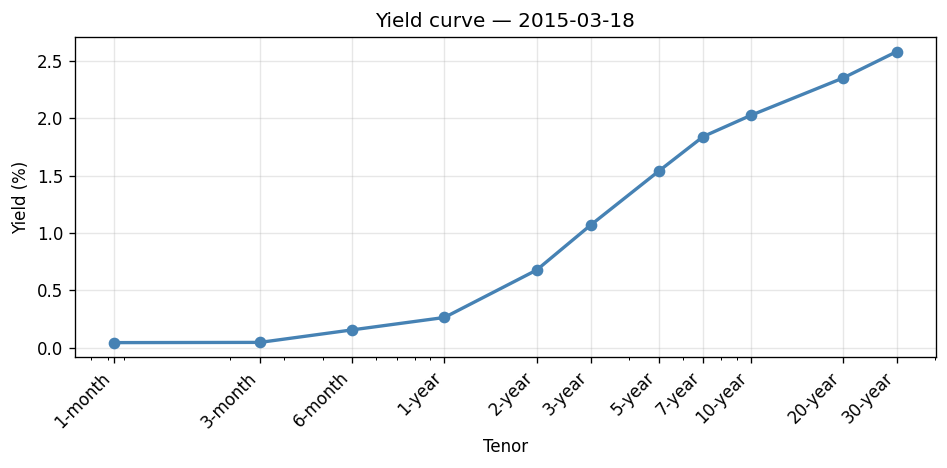

In [3]:
last_date = curve.index[-1]
last_curve = curve.loc[last_date]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(TENOR_YEARS, last_curve.values, marker="o", color="steelblue", lw=2)
ax.set_xscale("log")
ax.set_xticks(TENOR_YEARS)
ax.set_xticklabels(TENORS, rotation=45, ha="right")
ax.set(xlabel="Tenor", ylabel="Yield (%)", title=f"Yield curve — {last_date.date()}")
plt.tight_layout()
plt.show()

## 3. Interest rate surface

The full daily grid has 6000+ dates; we resample to month-start observations
so the 3D surface stays readable, then plot tenor × time × yield as a surface
next to the equivalent heatmap.

/var/folders/jz/kmcv6z957nb55q23tfvb3kd40000gn/T/ipykernel_85490/22523583.py:40: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


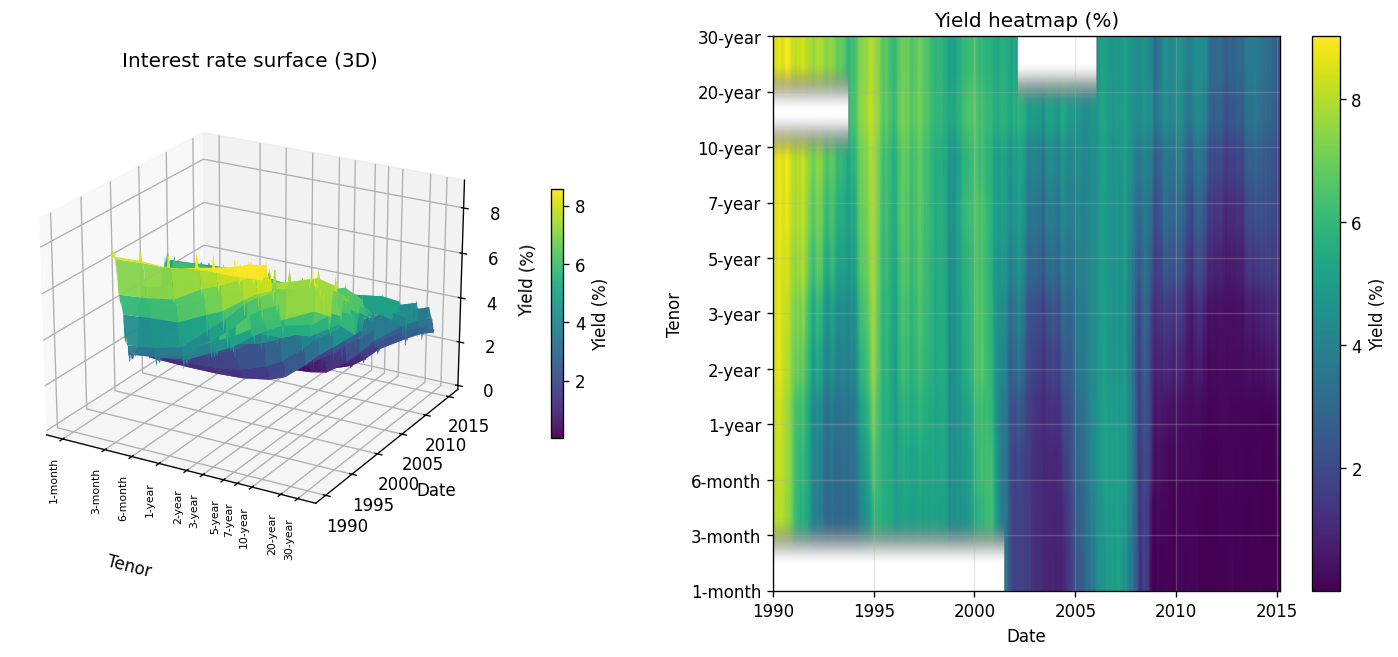

In [4]:
monthly = curve.resample("MS").mean()

X = np.array(TENOR_YEARS)                       # tenor axis (years, log-spaced)
Y = mdates.date2num(monthly.index.to_pydatetime())  # time axis
Z = monthly.values                               # shape (n_dates, n_tenors), in %

T_grid, D_grid = np.meshgrid(X, Y)

fig = plt.figure(figsize=(15, 6))

# -- Surface 3D --
ax3d = fig.add_subplot(121, projection="3d")
surf = ax3d.plot_surface(np.log10(T_grid), D_grid, Z, cmap="viridis",
                          edgecolor="none", alpha=0.95)
ax3d.set_xlabel("Tenor", labelpad=22)
ax3d.set_xticks(np.log10(X))
ax3d.set_xticklabels(TENORS, fontsize=6.5, rotation=90)
ax3d.tick_params(axis="x", pad=0)
ax3d.set_ylabel("Date")
ax3d.yaxis.set_major_locator(mdates.YearLocator(5))
ax3d.yaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax3d.set_zlabel("Yield (%)")
ax3d.set_title("Interest rate surface (3D)")
ax3d.view_init(elev=22, azim=-60)
fig.colorbar(surf, ax=ax3d, shrink=0.45, label="Yield (%)", pad=0.1)

# -- Heatmap 2D --
ax2d = fig.add_subplot(122)
im = ax2d.imshow(Z.T, aspect="auto", origin="lower", cmap="viridis",
                  extent=[Y[0], Y[-1], 0, len(TENORS) - 1])
ax2d.set_yticks(range(len(TENORS)))
ax2d.set_yticklabels(TENORS)
ax2d.xaxis.set_major_locator(mdates.YearLocator(5))
ax2d.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2d.set_xlabel("Date")
ax2d.set_ylabel("Tenor")
ax2d.set_title("Yield heatmap (%)")
fig.colorbar(im, ax=ax2d, label="Yield (%)")

plt.tight_layout()
plt.show()

## 4. Interactive surface (Plotly)

Same monthly grid, rendered as an interactive `go.Surface` so tenor/date/yield
can be inspected on hover.

In [5]:
fig = go.Figure(data=go.Surface(
    x=TENORS,
    y=monthly.index,
    z=Z,
    colorscale="Viridis",
    colorbar=dict(title="Yield (%)"),
    hovertemplate="Tenor: %{x}<br>Date: %{y}<br>Yield: %{z:.2f}%<extra></extra>",
))
fig.update_layout(
    title="Interest rate surface",
    scene=dict(
        xaxis_title="Tenor",
        yaxis_title="Date",
        zaxis_title="Yield (%)",
    ),
    width=900, height=650,
    margin=dict(l=0, r=0, b=0, t=40),
)
fig.show()